<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

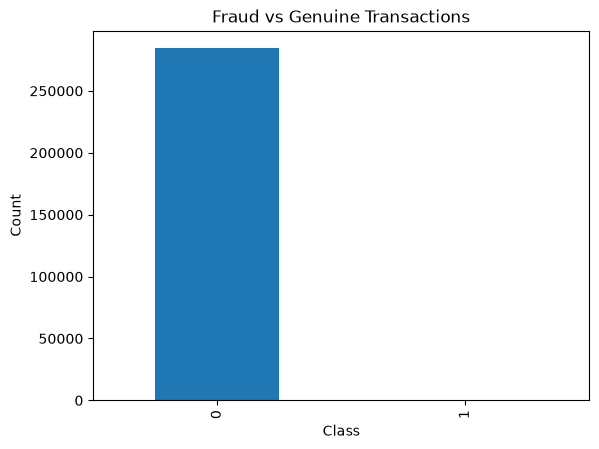

Precision : 0.9411764705882353
Recall : 0.8163265306122449
F1 Score : 0.8743169398907104
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



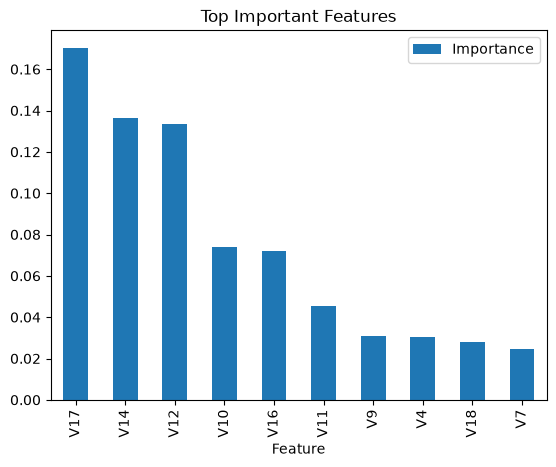

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score
)
credit_data = pd.read_csv("creditcard.csv")

credit_data.head()
credit_data.info()
credit_data.isnull().sum()
credit_data["Class"].value_counts()
credit_data["Class"].value_counts().plot(
    kind="bar"
)

plt.title("Fraud vs Genuine Transactions")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()
input_data = credit_data.drop(
    "Class",
    axis=1
)

output_data = credit_data["Class"]
x_train, x_test, y_train, y_test = train_test_split(
    input_data,
    output_data,
    test_size=0.2,
    random_state=42,
    stratify=output_data
)
fraud_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

fraud_model.fit(
    x_train,
    y_train
)
fraud_prediction = fraud_model.predict(
    x_test
)
precision = precision_score(
    y_test,
    fraud_prediction
)

print("Precision :", precision)
recall = recall_score(
    y_test,
    fraud_prediction
)

print("Recall :", recall)
f1 = f1_score(
    y_test,
    fraud_prediction
)

print("F1 Score :", f1)
print(
    classification_report(
        y_test,
        fraud_prediction
    )
)
feature_importance = pd.DataFrame({
    "Feature": input_data.columns,
    "Importance": fraud_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10).plot(
    x="Feature",
    y="Importance",
    kind="bar"
)

plt.title("Top Important Features")
plt.show()

